In [11]:
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_groq import ChatGroq
from langgraph.prebuilt import ToolNode
from typing import TypedDict, Annotated, Sequence, Literal
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pathlib import Path
import yaml

from RAG.tavily_rag import search_web
from RAG.offline_rag import search_local_books
from LLM.prompt_templates import SYSTEM_PROMPT
from LLM.react_agent import AgentState, make_react_agent

load_dotenv()

# Config 
# --------
CONFIG_PATH = Path("config.yaml")

def load_config():
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

config = load_config()

# LLM + Tools 
# -----------
tools = [search_web, search_local_books]
tools_dict = {our_tool.name: our_tool for our_tool in tools} # Creating a dictionary of our tools
llm = ChatGroq(model=config["LLM"]["model"],
            temperature=0.7)
llm_with_tools = llm.bind_tools(tools)

# ReAct agent
# -------------
react_agent = make_react_agent(llm_with_tools)

# Routing Functions 
# -------------------
def should_continue(state: AgentState):
    """Check if the last message contains tool calls."""
    result = state['messages'][-1]
    return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0

# 2. retriever agent
def take_action(state: AgentState) -> AgentState:
    """Execute tool calls from the LLM's response."""

    tool_calls = state['messages'][-1].tool_calls
    results = []
    
    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}")
        
        if not t['name'] in tools_dict: # Checks if a valid tool is present
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."
        
        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")
            

        # Appends the Tool Message
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {'messages': results}

# Build Graph 
# ------------
builder = StateGraph(AgentState)

# nodes
builder.add_node("react_agent", react_agent)
builder.add_node("retriever_agent", take_action)

# entry point goes straight to the agent
builder.add_edge(START, "react_agent")

# ReAct loop: react_agent → retriever_agent → react_agent → ... → end
builder.add_conditional_edges(
    "react_agent",
    take_action,
    {
        True: "retriever_agent", 
        False: END}
)
builder.add_edge("retriever_agent", "react_agent")   # tool results loop back to agent

# compile
tutor_graph = builder.compile()

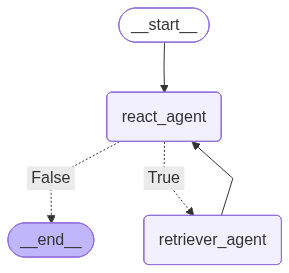

In [12]:
# Visulaize the graph
from IPython.display import Image, display
display(Image(tutor_graph.get_graph().draw_mermaid_png()))